# Lattice Frame Explorer — TE5 vs Z5

This notebook performs a small exploratory 3D frame analysis of simplified lattice-tower top geometries.

It is **not** a design/checking tool. It is intended only for comparing trends between two simplified models under user-defined loads.

Current models:

- `TE5`
- `Z5`

The input tables use canonical node and element IDs. Analogous nodes and analogous elements have the same IDs in both models.

## 1. Imports and global options

The default section mode is the more detailed idealized L-angle calculation using principal inertias. You can switch to the simpler `Iy = Iz` option by changing `SECTION_MODE` to `"isotropic"`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import (
    read_nodes,
    read_elements,
    model_summary,
    incident_summary,
    topology_check,
    make_loads_from_labels,
    solve_model,
    compare_results,
    save_result_tables,
    plot_geometry,
    plot_stress_3d,
    plot_deformed_shape,
    build_sections,
)

DATA_DIR = Path("data")
RESULTS_DIR = Path("results/notebook_run")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Section-property option:
# "principal" = idealized L-angle principal inertias, default/recommended for exploration.
# "isotropic" = simplified option, Iy = Iz = Iavg.
SECTION_MODE = "principal"

# Only used when SECTION_MODE = "principal".
# "strong-inward" assigns Imax to the local inward-projected bending axis.
# "weak-inward" swaps Imax/Imin and is useful as a sensitivity check.
ORIENTATION_RULE = "strong-inward"

MODELS = {
    "TE5": {
        "nodes": DATA_DIR / "TE5_nodes_aligned.csv",
        "elements": DATA_DIR / "TE5_elements_with_sections.csv",
    },
    "Z5": {
        "nodes": DATA_DIR / "Z5_nodes_aligned.csv",
        "elements": DATA_DIR / "Z5_elements_with_sections.csv",
    },
}

## 2. Read the model geometry

Each node has six frame DOFs:

```text
Ux, Uy, Uz, Rx, Ry, Rz
```

The bottom four nodes are fully fixed. The two high points are marked as default load points.

In [2]:
models = {}
for name, paths in MODELS.items():
    nodes = read_nodes(paths["nodes"])
    elements = read_elements(paths["elements"])
    models[name] = {"nodes": nodes, "elements": elements}

for name, model in models.items():
    print(f"\n{name} node/element summary")
    display(model_summary(model["nodes"], model["elements"]))


TE5 node/element summary


,quantity,value
0,nodes,44.000000
1,elements,110.000000
2,fixed_support_nodes,4.000000
3,load_point_nodes,2.000000
4,x_min_mm,-3500.000000
5,x_max_mm,3500.000000
6,y_min_mm,-1197.561576
7,y_max_mm,1197.561576
8,z_min_mm,0.000000
9,z_max_mm,7050.000000



Z5 node/element summary


,quantity,value
0,nodes,40.0
1,elements,104.0
2,fixed_support_nodes,4.0
3,load_point_nodes,2.0
4,x_min_mm,-4200.0
5,x_max_mm,4200.0
6,y_min_mm,-1319.5
7,y_max_mm,1319.5
8,z_min_mm,0.0
9,z_max_mm,7100.0


## 3. Canonical topology check

The high-point topology should be symmetric. Each high point should have three incident members:

```text
center -> high point
high point -> top_ypos
high point -> top_yneg
```

In [3]:
for name, model in models.items():
    print(f"\n{name}: incident members at load points")
    display(incident_summary(model["elements"], labels=("high_xneg", "high_xpos")))
    print(topology_check(model["nodes"], model["elements"]))


TE5: incident members at load points


,node_label,incident_element_count,incident_element_ids,connected_to
0,high_xneg,3,"24, 28, 32","te5_e00_d3228_from_base, te5_e02_d4015_from_ba..."
1,high_xpos,3,"27, 36, 40","te5_e01_d3228_from_base, te5_e04_d4015_from_ba..."


{'node_count': 44, 'element_count': 110, 'missing_node_references': [], 'connected_component_count': 1, 'connected_components': [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]], 'high_xneg_incident_count': 3, 'high_xpos_incident_count': 3}

Z5: incident members at load points


,node_label,incident_element_count,incident_element_ids,connected_to
0,high_xneg,3,"22, 26, 41","z5_e02_top_xneg_ypos_d4906, z5_e03_top_xneg_yn..."
1,high_xpos,3,"30, 34, 45","z5_e04_top_xpos_ypos_d4906, z5_e05_top_xpos_yn..."


{'node_count': 40, 'element_count': 104, 'missing_node_references': [], 'connected_component_count': 1, 'connected_components': [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]], 'high_xneg_incident_count': 3, 'high_xpos_incident_count': 3}


## 4. Element section assignments

The `member_role` and `element_id` conventions are aligned between `TE5` and `Z5`.

Top-square sides are explicitly split into:

- `top_square_x_side`
- `top_square_y_side`

In [4]:
cols = ["element_id", "start_label", "end_label", "member_role", "section_name", "b1_mm", "b2_mm", "t_mm"]
for name, model in models.items():
    print(f"\n{name} element assignments")
    display(model["elements"][cols])


TE5 element assignments


,element_id,start_label,end_label,member_role,section_name,b1_mm,b2_mm,t_mm
0,6,center,top_xneg_ypos,center_to_top,L90x90x7,90.0,90.0,7.0
1,7,center,top_xneg_yneg,center_to_top,L90x90x7,90.0,90.0,7.0
2,8,center,top_xpos_ypos,center_to_top,L90x90x7,90.0,90.0,7.0
3,9,center,top_xpos_yneg,center_to_top,L90x90x7,90.0,90.0,7.0
4,10,top_xneg_ypos,top_xneg_yneg,top_square_y_side,L80x80x5,80.0,80.0,5.0
...,...,...,...,...,...,...,...,...
105,119,te5_truss_xing_e103_105,base_xneg_ypos,lower_face_diagonal_node_to_opposite_base_spli...,L60x60x4,60.0,60.0,4.0
106,120,te5_truss_xing_e107_109,top_xpos_ypos,side_face_node_to_opposite_top_split_at_crossing,L60x60x4,60.0,60.0,4.0
107,121,te5_truss_xing_e107_109,top_xpos_yneg,side_face_node_to_opposite_top_split_at_crossing,L60x60x4,60.0,60.0,4.0
108,122,te5_truss_xing_e111_113,top_xneg_ypos,side_face_node_to_opposite_top_split_at_crossing,L60x60x4,60.0,60.0,4.0



Z5 element assignments


,element_id,start_label,end_label,member_role,section_name,b1_mm,b2_mm,t_mm
0,6,center,top_xneg_ypos,center_to_top,L102x102x6.4,102.0,102.0,6.4
1,7,center,top_xneg_yneg,center_to_top,L102x102x6.4,102.0,102.0,6.4
2,8,center,top_xpos_ypos,center_to_top,L102x102x6.4,102.0,102.0,6.4
3,9,center,top_xpos_yneg,center_to_top,L102x102x6.4,102.0,102.0,6.4
4,11,top_xneg_yneg,top_xpos_yneg,top_square_x_side,L89x76x6.4,89.0,76.0,6.4
...,...,...,...,...,...,...,...,...
99,167,z5_truss_xing_e136_137,top_xpos_yneg,top_square_diagonal_split_at_crossing,L45x45x4,45.0,45.0,4.0
100,168,z5_truss_xing_e154_155,base_xpos_yneg,lower_face_diagonal_yneg_split_at_crossing,L65x65x4,65.0,65.0,4.0
101,169,z5_truss_xing_e154_155,base_xneg_yneg,lower_face_diagonal_yneg_split_at_crossing,L65x65x4,65.0,65.0,4.0
102,170,z5_truss_xing_e156_157,base_xpos_ypos,lower_face_diagonal_ypos_split_at_crossing,L65x65x4,65.0,65.0,4.0


## 5. Geometry plots

Element IDs are annotated at member midpoints. This is useful for checking that analogous elements have the same IDs in `TE5` and `Z5`.

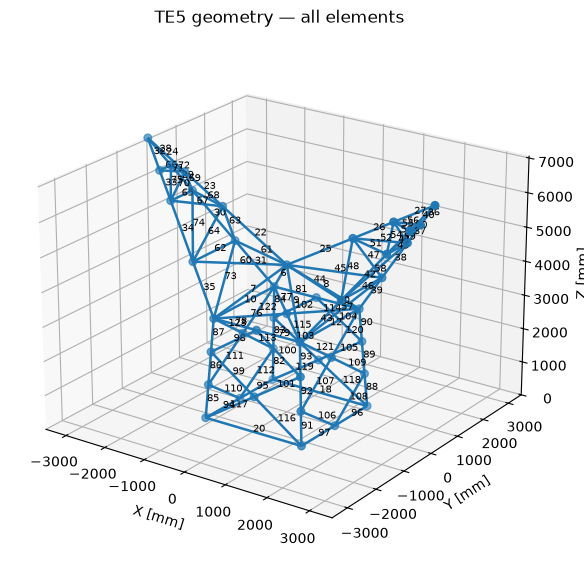

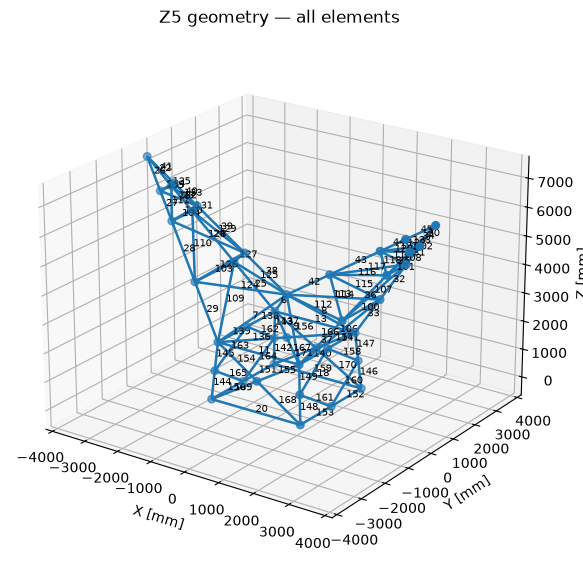

In [5]:
def select_elements(elements, element_type="all"):
    """
    element_type options:
        "all"   -> return all elements
        "frame" -> return only frame elements
        "truss" -> return only truss elements

    If the element_type column does not exist, assume all existing elements are frame elements.
    """
    elements = elements.copy()

    if "element_type" not in elements.columns:
        elements["element_type"] = "frame"

    if element_type == "all":
        return elements

    return elements.loc[
        elements["element_type"].fillna("frame").eq(element_type)
    ].copy()


def select_member_forces_for_elements(member_forces, elements_subset):
    """
    Filter member_forces so it contains only rows corresponding to the
    element_ids present in elements_subset.
    """
    keep_ids = set(elements_subset["element_id"].astype(int))

    return member_forces.loc[
        member_forces["element_id"].astype(int).isin(keep_ids)
    ].copy()

# for name, model in models.items():
#     fig, ax = plot_geometry(
#         model["nodes"],
#         model["elements"],
#         title=f"{name} geometry — node labels and element IDs",
#         annotate=True,
#         annotate_elements=True,
#     )
#     plt.show()

###################

# for name, model in models.items():
#     frame_elements = select_elements(model["elements"], element_type="frame")

#     fig, ax = plot_geometry(
#         model["nodes"],
#         frame_elements,
#         title=f"{name} geometry — frame elements only",
#         annotate=False,
#         annotate_elements=True,
#     )
#     plt.show()

for name, model in models.items():
    all_elements = select_elements(model["elements"], element_type="all")

    fig, ax = plot_geometry(
        model["nodes"],
        all_elements,
        title=f"{name} geometry — all elements",
        annotate=False,
        annotate_elements=True,
    )
    plt.show()



## 6. Section-property preview

The default `principal` mode computes idealized sharp-corner L-angle properties and uses the principal second moments.

The alternative `isotropic` mode uses:

```text
Iy = Iz = Iavg
```

This is less realistic for angle sections, but is useful for debugging and reducing sensitivity to local-axis orientation.

In [6]:
for mode in ["principal", "isotropic"]:
    print(f"\nSection preview with SECTION_MODE = {mode!r}")
    rows = []
    for name, model in models.items():
        section_df, _ = build_sections(model["elements"], section_mode=mode, orientation_rule=ORIENTATION_RULE)
        unique = (
            section_df[["section_name", "b1_mm", "b2_mm", "t_mm", "A_mm2", "Iy_mm4", "Iz_mm4", "J_mm4", "Imin_mm4", "Imax_mm4", "Iavg_mm4"]]
            .drop_duplicates("section_name")
            .copy()
        )
        unique.insert(0, "model", name)
        rows.append(unique)
    display(pd.concat(rows, ignore_index=True))


Section preview with SECTION_MODE = 'principal'


,model,section_name,b1_mm,b2_mm,t_mm,A_mm2,Iy_mm4,Iz_mm4,J_mm4,Imin_mm4,Imax_mm4,Iavg_mm4
0,TE5,L90x90x7,90.0,90.0,7.0,1211.00,1.512640e+06,383719.974470,19779.666667,383719.974470,1.512640e+06,9.481799e+05
1,TE5,L80x80x5,80.0,80.0,5.0,775.00,7.766146e+05,195969.422043,6458.333333,195969.422043,7.766146e+05,4.862920e+05
2,TE5,L102x89x6.4,102.0,89.0,6.4,1181.44,1.704235e+06,412164.096251,16130.594133,412164.096251,1.704235e+06,1.058200e+06
3,TE5,L45x45x4,45.0,45.0,4.0,344.00,1.062387e+05,27075.294574,1834.666667,27075.294574,1.062387e+05,6.665698e+04
4,TE5,L50x50x4,50.0,50.0,4.0,384.00,1.477120e+05,37503.666667,2048.000000,37503.666667,1.477120e+05,9.260783e+04
5,TE5,L76x64x4.8,76.0,64.0,4.8,648.96,5.063717e+05,119464.773775,4984.012800,119464.773775,5.063717e+05,3.129182e+05
6,TE5,L102x102x7.9,102.0,102.0,7.9,1549.19,2.486296e+06,630633.390844,32228.315967,630633.390844,2.486296e+06,1.558465e+06
7,TE5,L60x60x4,60.0,60.0,4.0,464.00,2.604587e+05,65810.390805,2474.666667,65810.390805,2.604587e+05,1.631345e+05
8,Z5,L102x102x6.4,102.0,102.0,6.4,1264.64,2.059610e+06,519756.910968,17266.551467,519756.910968,2.059610e+06,1.289683e+06
9,Z5,L89x76x6.4,89.0,76.0,6.4,1015.04,1.086739e+06,259831.235758,13858.679467,259831.235758,1.086739e+06,6.732849e+05



Section preview with SECTION_MODE = 'isotropic'


,model,section_name,b1_mm,b2_mm,t_mm,A_mm2,Iy_mm4,Iz_mm4,J_mm4,Imin_mm4,Imax_mm4,Iavg_mm4
0,TE5,L90x90x7,90.0,90.0,7.0,1211.00,9.481799e+05,9.481799e+05,19779.666667,383719.974470,1.512640e+06,9.481799e+05
1,TE5,L80x80x5,80.0,80.0,5.0,775.00,4.862920e+05,4.862920e+05,6458.333333,195969.422043,7.766146e+05,4.862920e+05
2,TE5,L102x89x6.4,102.0,89.0,6.4,1181.44,1.058200e+06,1.058200e+06,16130.594133,412164.096251,1.704235e+06,1.058200e+06
3,TE5,L45x45x4,45.0,45.0,4.0,344.00,6.665698e+04,6.665698e+04,1834.666667,27075.294574,1.062387e+05,6.665698e+04
4,TE5,L50x50x4,50.0,50.0,4.0,384.00,9.260783e+04,9.260783e+04,2048.000000,37503.666667,1.477120e+05,9.260783e+04
5,TE5,L76x64x4.8,76.0,64.0,4.8,648.96,3.129182e+05,3.129182e+05,4984.012800,119464.773775,5.063717e+05,3.129182e+05
6,TE5,L102x102x7.9,102.0,102.0,7.9,1549.19,1.558465e+06,1.558465e+06,32228.315967,630633.390844,2.486296e+06,1.558465e+06
7,TE5,L60x60x4,60.0,60.0,4.0,464.00,1.631345e+05,1.631345e+05,2474.666667,65810.390805,2.604587e+05,1.631345e+05
8,Z5,L102x102x6.4,102.0,102.0,6.4,1264.64,1.289683e+06,1.289683e+06,17266.551467,519756.910968,2.059610e+06,1.289683e+06
9,Z5,L89x76x6.4,89.0,76.0,6.4,1015.04,6.732849e+05,6.732849e+05,13858.679467,259831.235758,1.086739e+06,6.732849e+05


## 7. User load input cell

Edit this cell to experiment with different loading conditions.

DOF/load convention:

```text
Fx = force along global X [N]       # longitudinal/transverse depending on your chosen global model axis
Fy = force along global Y [N]       # longitudinal/transverse depending on your chosen global model axis
Fz = force along global Z [N]       # vertical; negative is downward
Mx = nodal moment about global X [N·mm]
My = nodal moment about global Y [N·mm]
Mz = nodal moment about global Z [N·mm]
```

The default case applies `13.4 kN` downward at each high point.

In [7]:
# USER LOAD INPUT CELL
# Edit Fx, Fy, Fz, Mx, My, Mz as needed.
# Units: forces in N, moments in N·mm.
# Fx: global X force
# Fy: global Y force
# Fz: global Z force; negative is downward
# Mx: moment about global X
# My: moment about global Y
# Mz: moment about global Z

LOAD_CASE_BY_LABEL = [
    {"node_label": "high_xneg", "Fx": 0.0, "Fy": 0.0, "Fz": -24000.0, "Mx": 0.0, "My": 0.0, "Mz": 0.0},
    {"node_label": "high_xpos", "Fx": 0.0, "Fy": 0.0, "Fz": -24000.0, "Mx": 0.0, "My": 0.0, "Mz": 0.0},
]

loads_by_model = {}
for name, model in models.items():
    loads_by_model[name] = make_loads_from_labels(model["nodes"], LOAD_CASE_BY_LABEL)
    print(f"\n{name} loads")
    display(loads_by_model[name].loc[(loads_by_model[name][["Fx", "Fy", "Fz", "Mx", "My", "Mz"]].abs().sum(axis=1) > 0)])


TE5 loads


,node_id,Fx,Fy,Fz,Mx,My,Mz
1,1,0.0,0.0,-24000.0,0.0,0.0,0.0
2,2,0.0,0.0,-24000.0,0.0,0.0,0.0



Z5 loads


,node_id,Fx,Fy,Fz,Mx,My,Mz
1,1,0.0,0.0,-24000.0,0.0,0.0,0.0
2,2,0.0,0.0,-24000.0,0.0,0.0,0.0


## 8. Solve the selected section mode

In [8]:
results = {}
for name, model in models.items():
    results[name] = solve_model(
        model["nodes"],
        model["elements"],
        loads_by_model[name],
        section_mode=SECTION_MODE,
        orientation_rule=ORIENTATION_RULE,
    )

summary = compare_results(results)
display(summary)

,model,section_mode,orientation_rule,max_translation_mm,max_abs_Uz_mm,max_abs_N_kN,max_M_resultant_kNmm,max_sigma_MPa,critical_element_id,critical_member,critical_section,total_Fx_N,total_Fy_N,total_Fz_N,support_Rx_N,support_Ry_N,support_Rz_N,condition_number
0,TE5,principal,strong-inward,3.548763,2.356878,32.781054,228.728701,40.577498,28,high_xneg -> te5_e02_d4015_from_base,L90x90x7,0.0,0.0,-48000.0,-3.451532e-10,-5.055654e-10,48000.0,7.460668e+07
1,Z5,principal,strong-inward,5.188946,3.254542,37.424336,291.414406,42.771809,30,high_xpos -> z5_e04_top_xpos_ypos_d4906,L102x102x6.4,0.0,0.0,-48000.0,1.992248e-09,1.149715e-09,48000.0,1.274611e+08


## 9. Critical members

The table below sorts members by the exact maximum normal stress evaluated over the idealized L-angle corner vertices at the two element ends.

In [9]:
# critical_tables = []
# for name, res in results.items():
#     table = res["member_forces"].sort_values("sigma_max_abs_MPa", ascending=False).head(10).copy()
#     table.insert(0, "model", name)
#     critical_tables.append(table)
# critical = pd.concat(critical_tables, ignore_index=True)
# display(critical[[
#     "model", "element_id", "start_label", "end_label", "member_role", "section_name",
#     "axial_state","axial_force_signed_N","max_abs_N_N", "max_M_resultant_Nmm", "sigma_max_abs_MPa"
# ]])

DISPLAY_COLS = [
    "model",
    "element_id",
    "start_label",
    "end_label",
    "member_role",
    "section_name",
    "axial_state",
    "sigma_max_abs_MPa",
    "axial_force_signed_N",
    "max_abs_N_N",
    "max_M_resultant_Nmm",
]


critical_tables = []

for name, res in results.items():
    table = (
        res["member_forces"]
        .sort_values("sigma_max_abs_MPa", ascending=False)
        .head(10)
        .copy()
    )
    table.insert(0, "model", name)
    critical_tables.append(table)

critical = pd.concat(critical_tables, ignore_index=True)

display(critical[DISPLAY_COLS])

,model,element_id,start_label,end_label,member_role,section_name,axial_state,sigma_max_abs_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm
0,TE5,28,high_xneg,te5_e02_d4015_from_base,load_point_to_top,L90x90x7,compression,40.577498,-26120.354258,26120.354258,228728.701389
1,TE5,36,high_xpos,te5_e04_d4015_from_base,load_point_to_top,L90x90x7,compression,40.577498,-26120.354258,26120.354258,228728.701389
2,TE5,37,te5_e04_d4015_from_base,te5_e04_d3185_from_base,load_point_to_top,L90x90x7,compression,37.901322,-25975.324197,25975.324197,224149.042021
3,TE5,29,te5_e02_d4015_from_base,te5_e02_d3185_from_base,load_point_to_top,L90x90x7,compression,37.901322,-25975.324197,25975.324197,224149.042021
4,TE5,24,te5_e00_d3228_from_base,high_xneg,load_point_to_center,L90x90x7,tension,34.722647,31780.906623,31780.906623,91697.833164
5,TE5,27,te5_e01_d3228_from_base,high_xpos,load_point_to_center,L90x90x7,tension,34.722647,31780.906623,31780.906623,91697.833164
6,TE5,26,te5_e01_d2020_from_base,te5_e01_d3228_from_base,load_point_to_center,L90x90x7,tension,33.241167,32699.438440,32699.438440,67698.526681
7,TE5,23,te5_e00_d2020_from_base,te5_e00_d3228_from_base,load_point_to_center,L90x90x7,tension,33.241167,32699.438440,32699.438440,67698.526681
8,TE5,40,high_xpos,te5_e05_d4015_from_base,load_point_to_top,L90x90x7,compression,31.014009,-25212.189510,25212.189510,121847.531892
9,TE5,32,high_xneg,te5_e03_d4015_from_base,load_point_to_top,L90x90x7,compression,31.014009,-25212.189510,25212.189510,121847.531892


# 9a. All elements

In [10]:
all_element_tables = []

model_order = list(results.keys())

for name, res in results.items():
    table = res["member_forces"].copy()
    table.insert(0, "model", name)
    all_element_tables.append(table)

all_elements_ordered = pd.concat(all_element_tables, ignore_index=True)

# Preserve the same model order as the `results` dictionary.
all_elements_ordered["model"] = pd.Categorical(
    all_elements_ordered["model"],
    categories=model_order,
    ordered=True,
)

all_elements_ordered = all_elements_ordered.sort_values(
    ["model", "element_id"]
).reset_index(drop=True)

display(all_elements_ordered[DISPLAY_COLS])

,model,element_id,start_label,end_label,member_role,section_name,axial_state,sigma_max_abs_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm
0,TE5,6,center,top_xneg_ypos,center_to_top,L90x90x7,tension,16.462063,14511.094361,14511.094361,55764.356891
1,TE5,7,center,top_xneg_yneg,center_to_top,L90x90x7,tension,16.669829,14523.075564,14523.075564,58568.065461
2,TE5,8,center,top_xpos_ypos,center_to_top,L90x90x7,tension,16.462063,14511.094361,14511.094361,55764.356891
3,TE5,9,center,top_xpos_yneg,center_to_top,L90x90x7,tension,16.669829,14523.075564,14523.075564,58568.065461
4,TE5,10,top_xneg_ypos,top_xneg_yneg,top_square_y_side,L80x80x5,tension,2.205147,905.288485,905.288485,15510.598258
...,...,...,...,...,...,...,...,...,...,...,...
209,Z5,167,z5_truss_xing_e136_137,top_xpos_yneg,top_square_diagonal_split_at_crossing,L45x45x4,compression,12.177325,-3745.380755,3745.380755,4347.273931
210,Z5,168,z5_truss_xing_e154_155,base_xpos_yneg,lower_face_diagonal_yneg_split_at_crossing,L65x65x4,compression,9.389800,-3815.080788,3815.080788,10831.124336
211,Z5,169,z5_truss_xing_e154_155,base_xneg_yneg,lower_face_diagonal_yneg_split_at_crossing,L65x65x4,compression,9.389800,-3815.080788,3815.080788,10831.124336
212,Z5,170,z5_truss_xing_e156_157,base_xpos_ypos,lower_face_diagonal_ypos_split_at_crossing,L65x65x4,compression,9.528671,-3823.284591,3823.284591,9550.129527


# 9b. All elements alternating

In [11]:
all_element_tables = []

model_order = list(results.keys())  # expected order: ["TE5", "Z5"]

for name, res in results.items():
    table = res["member_forces"].copy()
    table.insert(0, "model", name)
    all_element_tables.append(table)

all_elements_alternating = pd.concat(all_element_tables, ignore_index=True)

# Preserve model display order, e.g. TE5 first, then Z5
all_elements_alternating["model"] = pd.Categorical(
    all_elements_alternating["model"],
    categories=model_order,
    ordered=True,
)

# Alternating order:
# TE5 element 0
# Z5  element 0
# TE5 element 1
# Z5  element 1
# ...
all_elements_alternating = all_elements_alternating.sort_values(
    ["element_id", "model"]
).reset_index(drop=True)

display(all_elements_alternating[DISPLAY_COLS])

,model,element_id,start_label,end_label,member_role,section_name,axial_state,sigma_max_abs_MPa,axial_force_signed_N,max_abs_N_N,max_M_resultant_Nmm
0,TE5,6,center,top_xneg_ypos,center_to_top,L90x90x7,tension,16.462063,14511.094361,14511.094361,55764.356891
1,Z5,6,center,top_xneg_ypos,center_to_top,L102x102x6.4,tension,17.967017,18324.555092,18324.555092,44567.779830
2,TE5,7,center,top_xneg_yneg,center_to_top,L90x90x7,tension,16.669829,14523.075564,14523.075564,58568.065461
3,Z5,7,center,top_xneg_yneg,center_to_top,L102x102x6.4,tension,18.403571,18336.612955,18336.612955,52418.716491
4,TE5,8,center,top_xpos_ypos,center_to_top,L90x90x7,tension,16.462063,14511.094361,14511.094361,55764.356891
...,...,...,...,...,...,...,...,...,...,...,...
209,Z5,167,z5_truss_xing_e136_137,top_xpos_yneg,top_square_diagonal_split_at_crossing,L45x45x4,compression,12.177325,-3745.380755,3745.380755,4347.273931
210,Z5,168,z5_truss_xing_e154_155,base_xpos_yneg,lower_face_diagonal_yneg_split_at_crossing,L65x65x4,compression,9.389800,-3815.080788,3815.080788,10831.124336
211,Z5,169,z5_truss_xing_e154_155,base_xneg_yneg,lower_face_diagonal_yneg_split_at_crossing,L65x65x4,compression,9.389800,-3815.080788,3815.080788,10831.124336
212,Z5,170,z5_truss_xing_e156_157,base_xpos_ypos,lower_face_diagonal_ypos_split_at_crossing,L65x65x4,compression,9.528671,-3823.284591,3823.284591,9550.129527


## 10. Stress visualization

The member colour corresponds to `sigma_max_abs_MPa`.

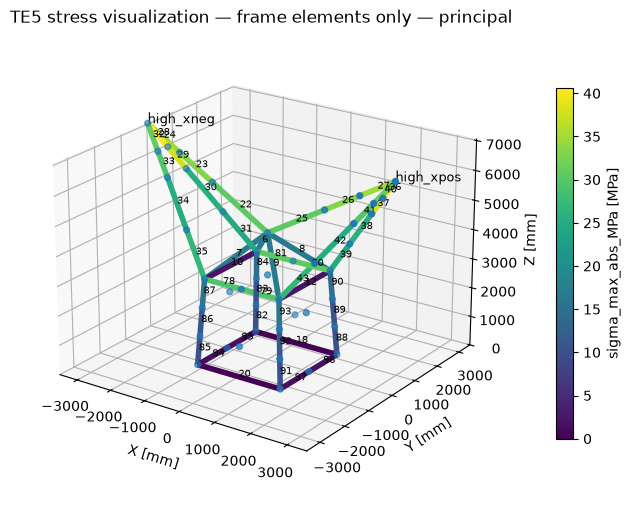

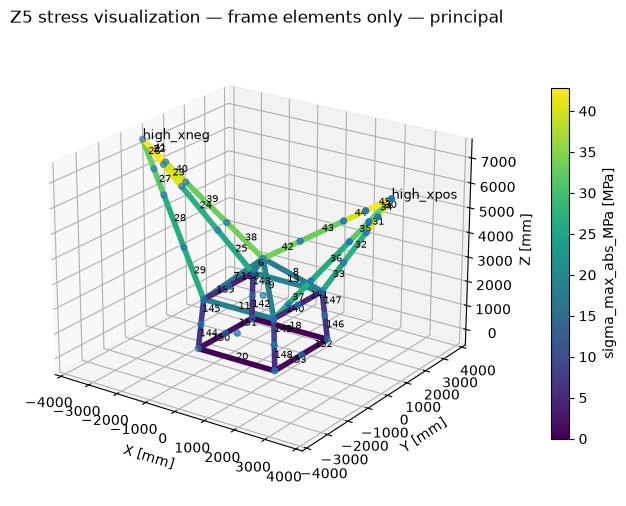

In [12]:
# for name, res in results.items():
#     fig, ax = plot_stress_3d(
#         res["nodes"],
#         res["elements"],
#         res["member_forces"],
#         title=f"{name} stress visualization — {SECTION_MODE}",
#         annotate_load_points=True,
#         annotate_elements=True,
#     )
#     plt.show()

for name, res in results.items():
    frame_elements = select_elements(res["elements"], element_type="frame")
    frame_forces = select_member_forces_for_elements(
        res["member_forces"],
        frame_elements,
    )

    fig, ax = plot_stress_3d(
        res["nodes"],
        frame_elements,
        frame_forces,
        title=f"{name} stress visualization — frame elements only — {SECTION_MODE}",
        annotate_load_points=True,
        annotate_elements=True,
    )
    plt.show()

## 11. Deformed shape visualization

The deformation is exaggerated for visibility.

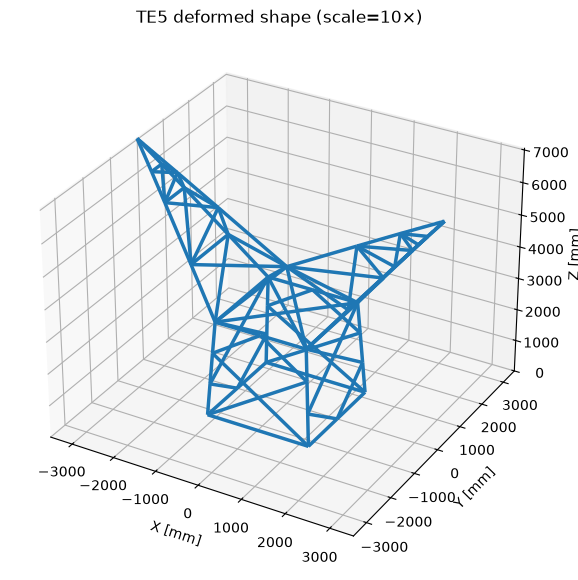

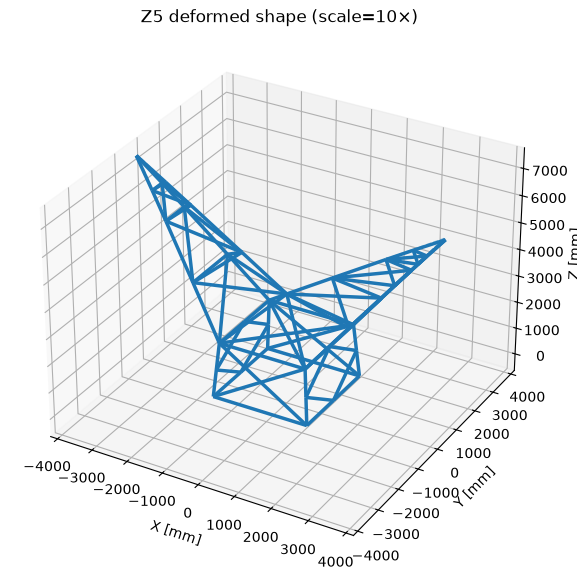

In [13]:
DEFORMATION_SCALE = 10.0
for name, res in results.items():
    fig, ax = plot_deformed_shape(
        res["nodes"],
        res["elements"],
        res["displacements"],
        scale=DEFORMATION_SCALE,
        title=f"{name} deformed shape",
    )
    plt.show()

## 12. Optional comparison of principal vs isotropic section modes

This cell reruns the same load case with both section-property assumptions, so you can see how much the `Iy`, `Iz` assumption affects the comparison.

In [14]:
mode_results = {}
for mode in ["principal", "isotropic"]:
    temp = {}
    for name, model in models.items():
        temp[name] = solve_model(
            model["nodes"],
            model["elements"],
            loads_by_model[name],
            section_mode=mode,
            orientation_rule=ORIENTATION_RULE,
        )
    s = compare_results(temp)
    s.insert(0, "mode", mode)
    mode_results[mode] = s

mode_comparison = pd.concat(mode_results.values(), ignore_index=True)
display(mode_comparison)

,mode,model,section_mode,orientation_rule,max_translation_mm,max_abs_Uz_mm,max_abs_N_kN,max_M_resultant_kNmm,max_sigma_MPa,critical_element_id,critical_member,critical_section,total_Fx_N,total_Fy_N,total_Fz_N,support_Rx_N,support_Ry_N,support_Rz_N,condition_number
0,principal,TE5,principal,strong-inward,3.548763,2.356878,32.781054,228.728701,40.577498,28,high_xneg -> te5_e02_d4015_from_base,L90x90x7,0.0,0.0,-48000.0,-3.451532e-10,-5.055654e-10,48000.0,7.460668e+07
1,principal,Z5,principal,strong-inward,5.188946,3.254542,37.424336,291.414406,42.771809,30,high_xpos -> z5_e04_top_xpos_ypos_d4906,L102x102x6.4,0.0,0.0,-48000.0,1.992248e-09,1.149715e-09,48000.0,1.274611e+08
2,isotropic,TE5,isotropic,strong-inward,3.517930,2.337703,32.734043,321.733988,39.063649,29,te5_e02_d4015_from_base -> te5_e02_d3185_from_...,L90x90x7,0.0,0.0,-48000.0,5.169341e-10,-5.287575e-10,48000.0,1.933908e+07
3,isotropic,Z5,isotropic,strong-inward,5.128383,3.220226,37.380560,428.174151,41.446503,31,z5_e04_top_xpos_ypos_d4906 -> z5_e04_top_xpos_...,L102x102x6.4,0.0,0.0,-48000.0,-6.275513e-11,-1.320018e-09,48000.0,3.342503e+07


## 13. Save result tables

In [15]:
save_result_tables(results, RESULTS_DIR)
critical[[
    "model", "element_id", "start_label", "end_label", "member_role", "section_name",
    "max_abs_N_N", "max_M_resultant_Nmm", "sigma_max_abs_MPa"
]].to_csv(RESULTS_DIR / "top_critical_members.csv", index=False)
mode_comparison.to_csv(RESULTS_DIR / "principal_vs_isotropic_summary.csv", index=False)

print(f"Saved notebook-run results to: {RESULTS_DIR}")

Saved notebook-run results to: results/notebook_run
